# 02 — Null experiment

**Purpose:** For each dataset and seed, compare observed Moran's I to the null distribution (permuted predictions), plot null histograms with observed line, report empirical p-values, and summarize fraction of significant runs.

## Imports and path setup

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.experiment_runner import _get_run_dirs
from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import load_config, load_meta, run_spatial, run_null

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb02")

## Load run artifacts and run null experiment

For each run we get preprocessed X_test via `analysis.preprocessing.get_transformed_test_features(run_dir, dataset_name)` so preprocessing matches training exactly. Then call `run_spatial` and `run_null` to get observed Moran's I and null distribution.

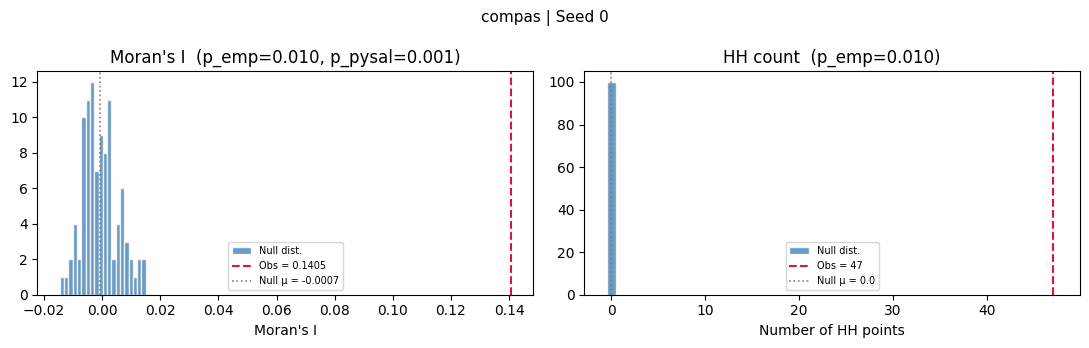

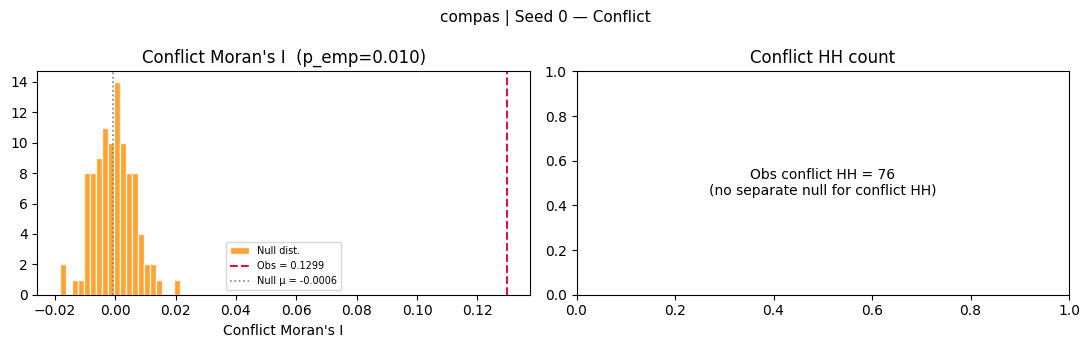

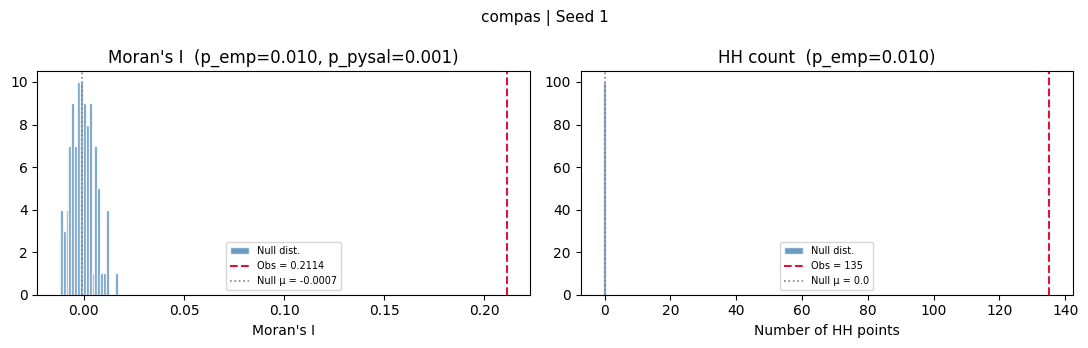

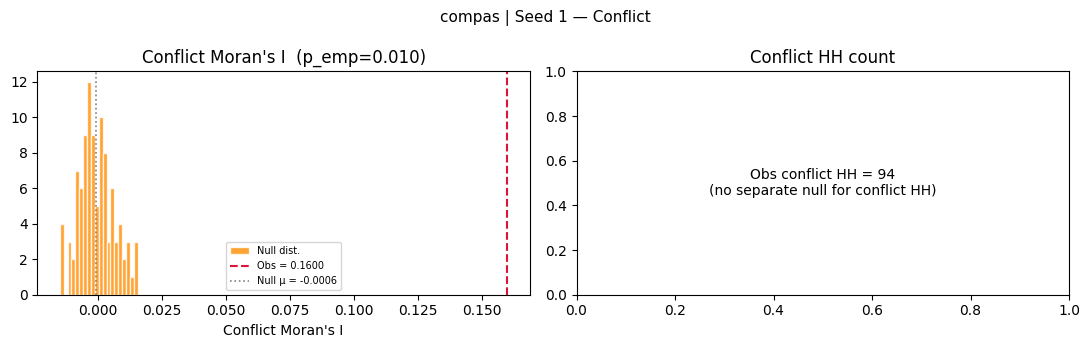

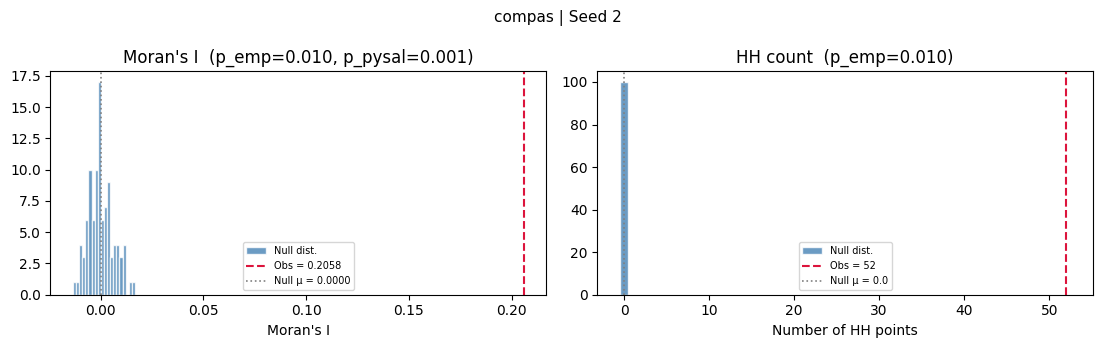

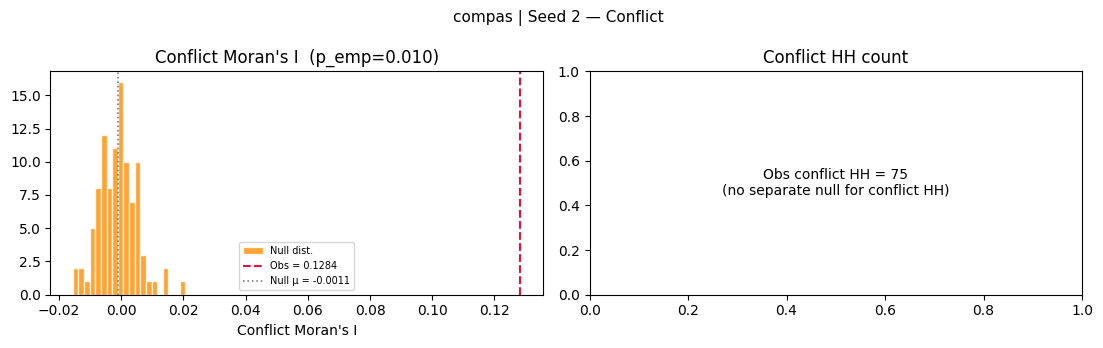

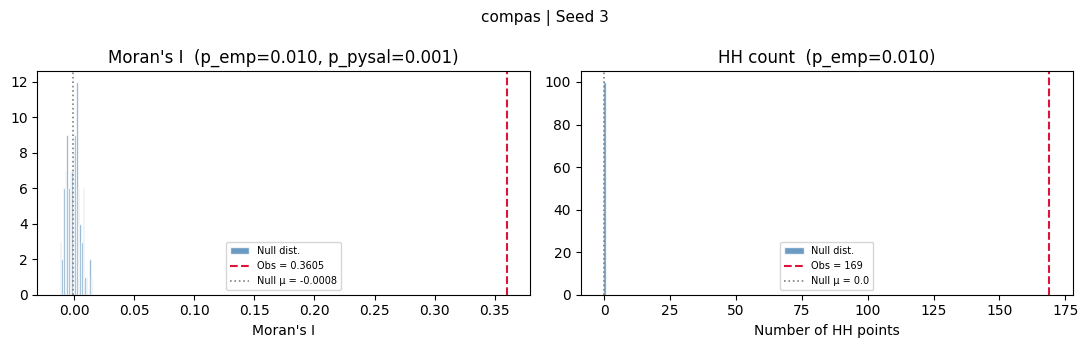

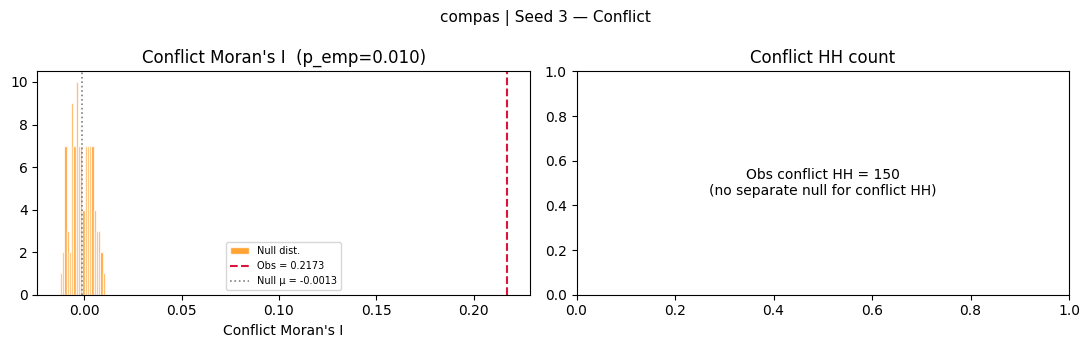

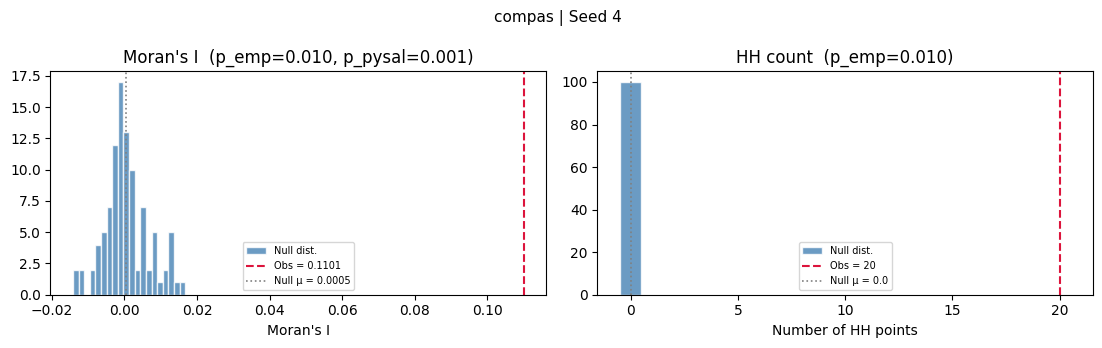

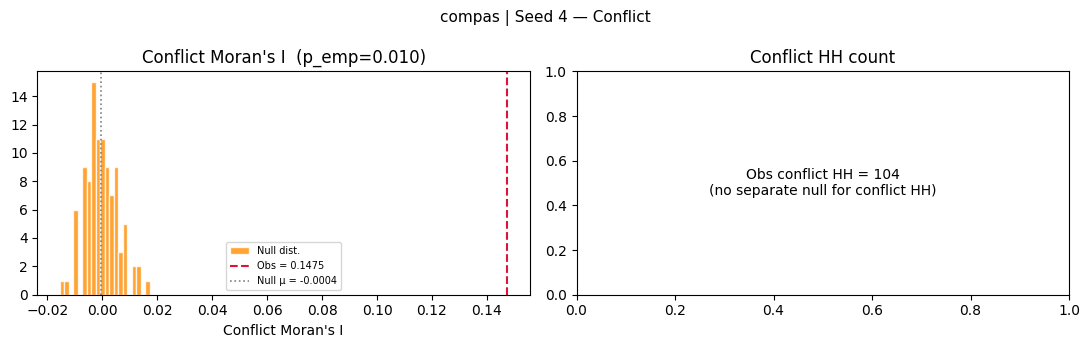

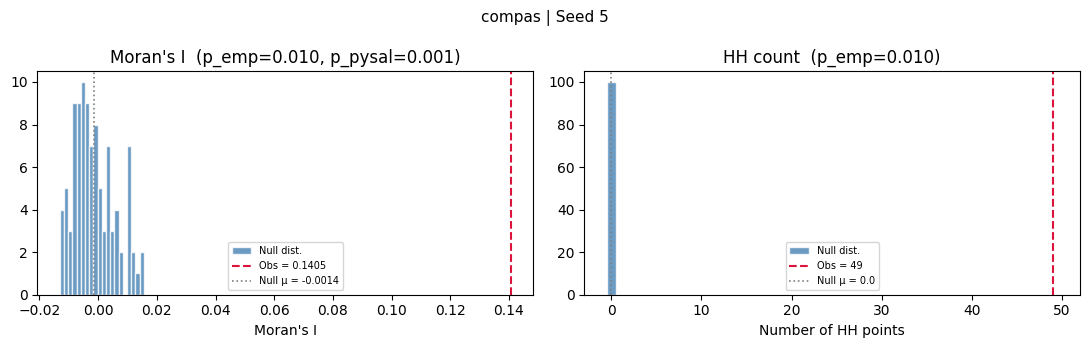

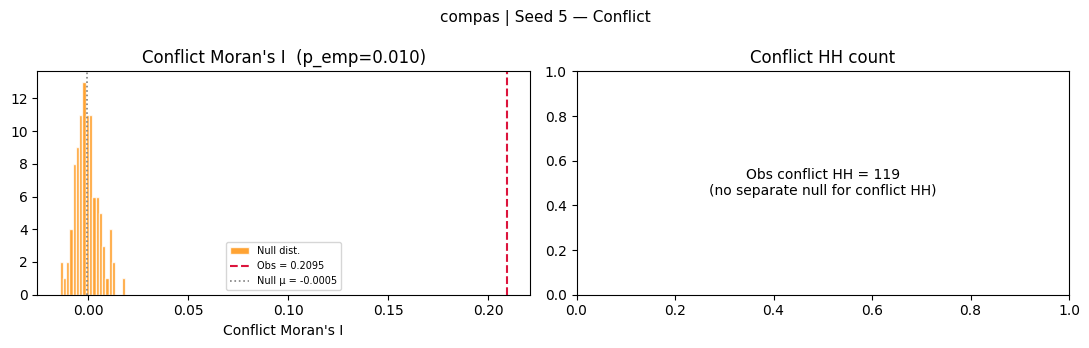

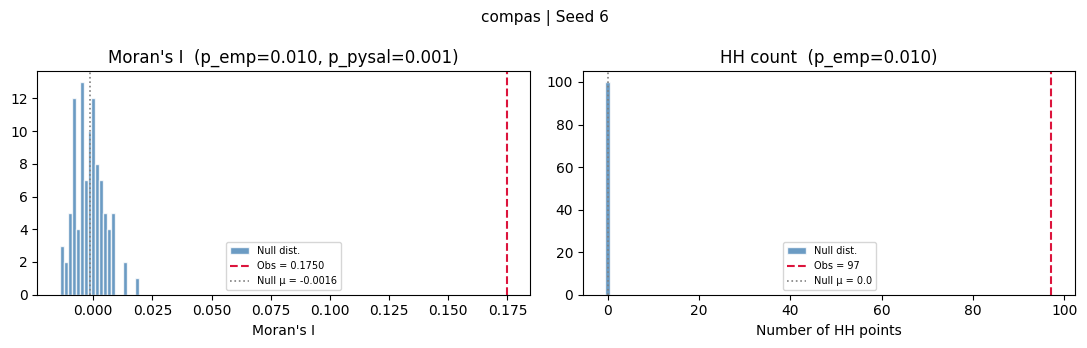

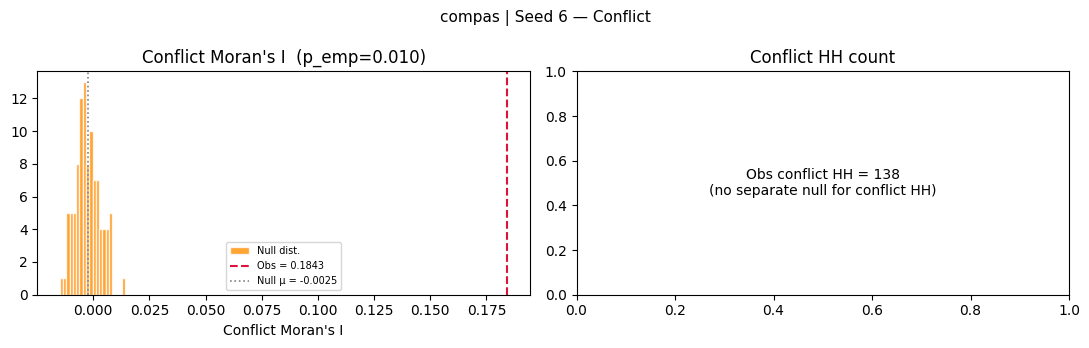

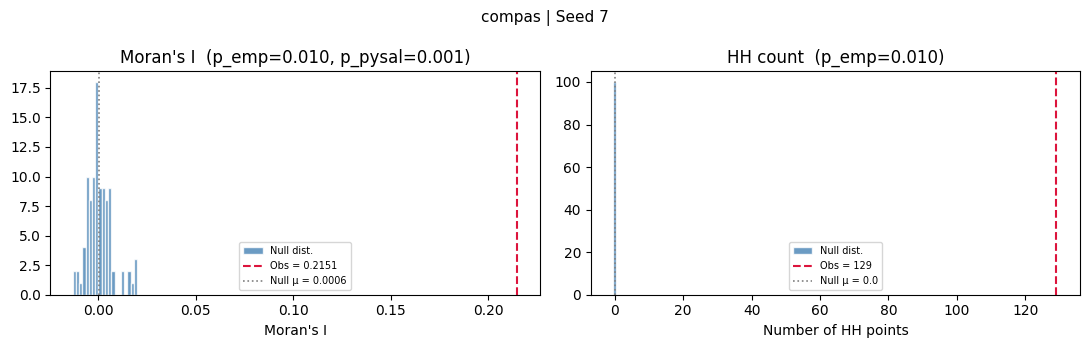

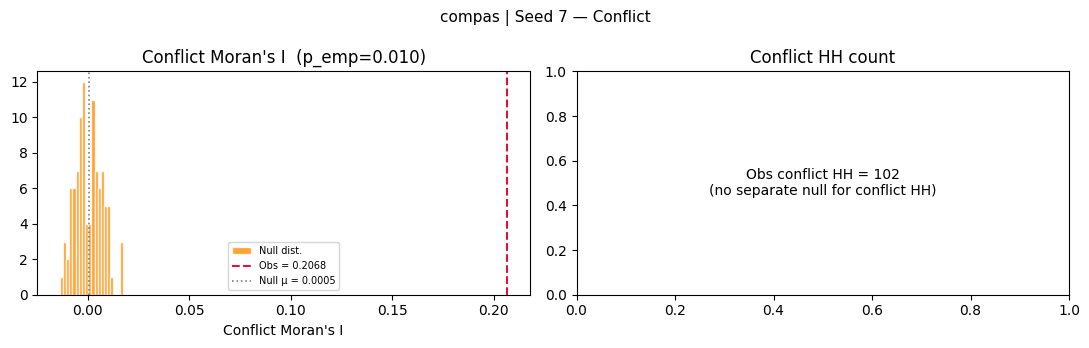

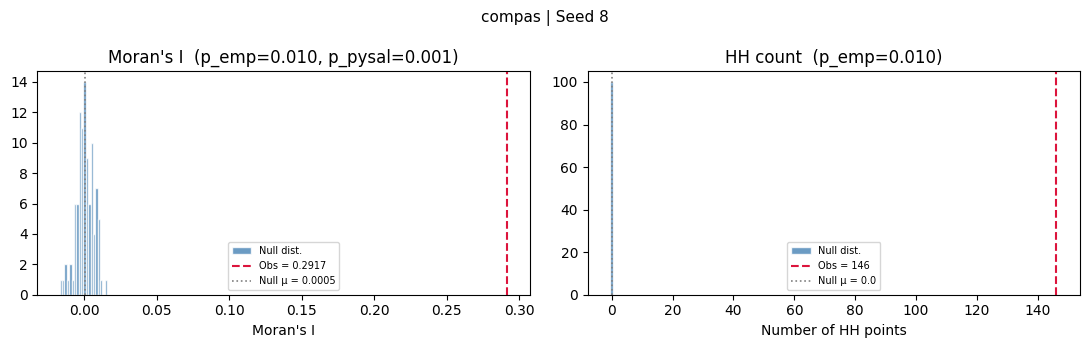

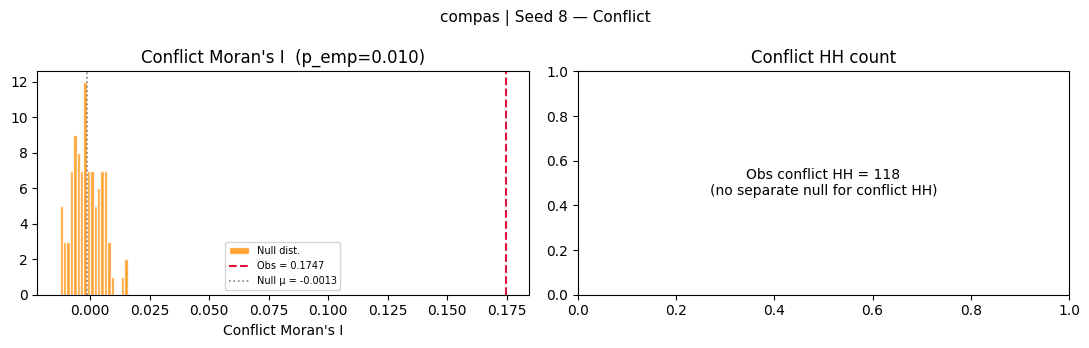

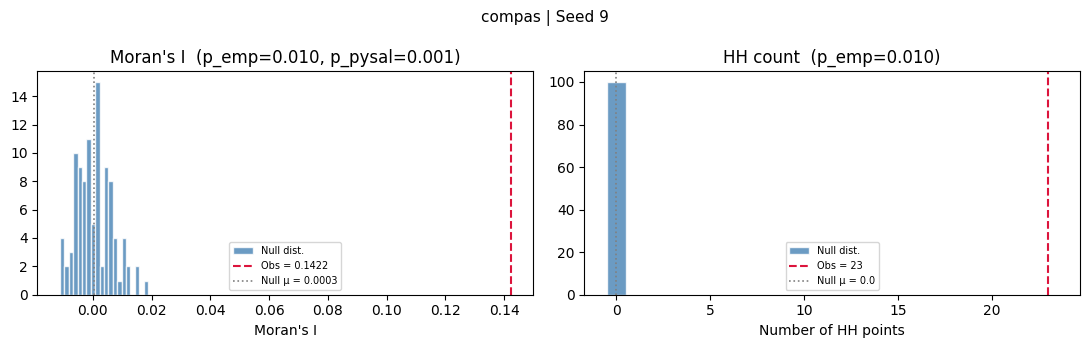

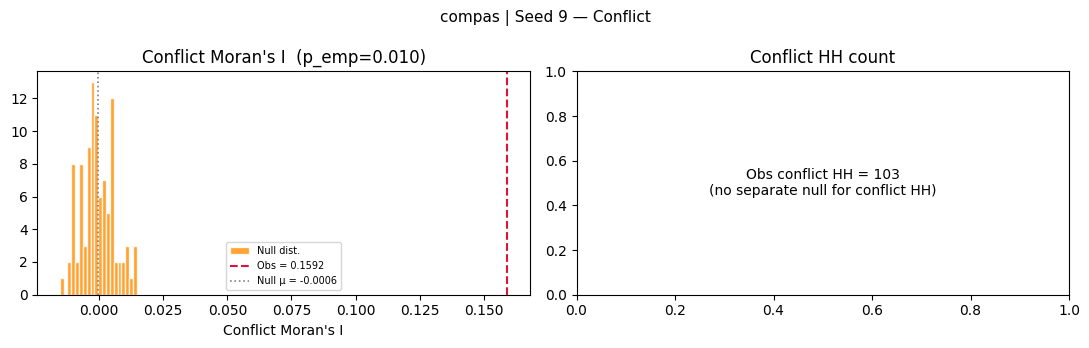

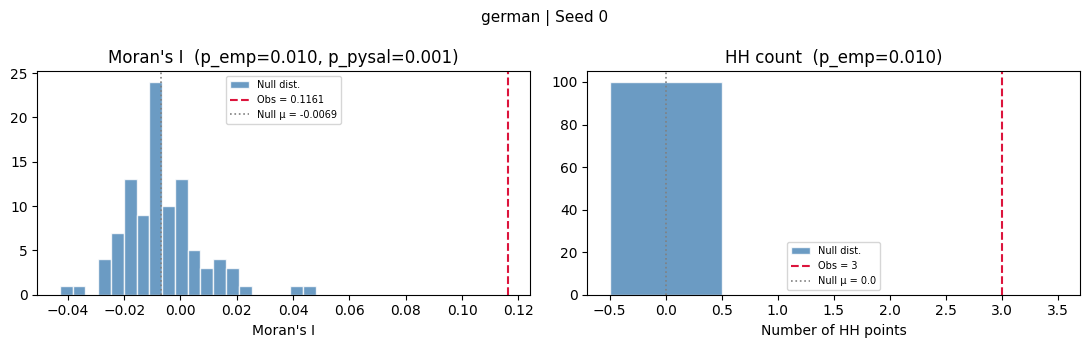

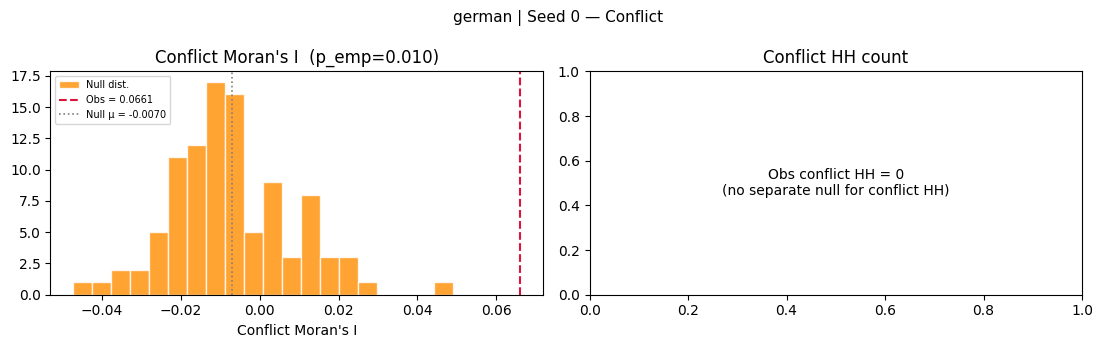

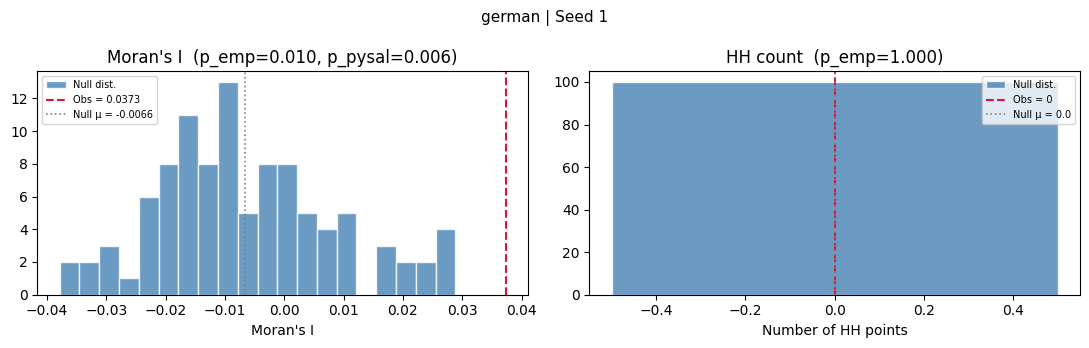

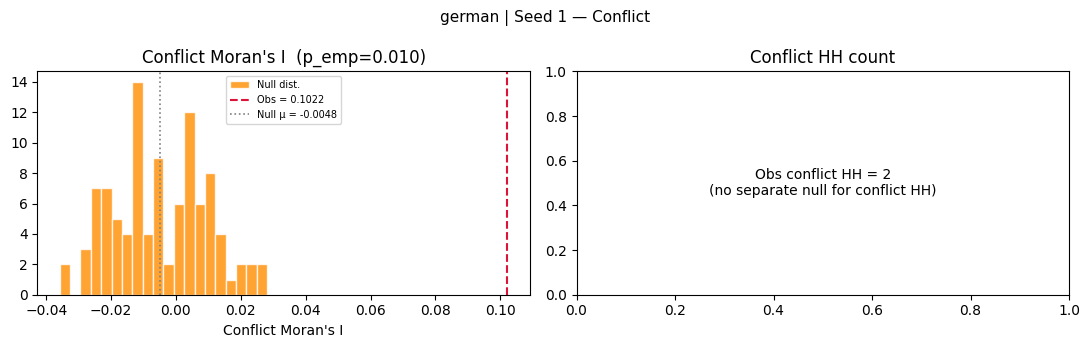

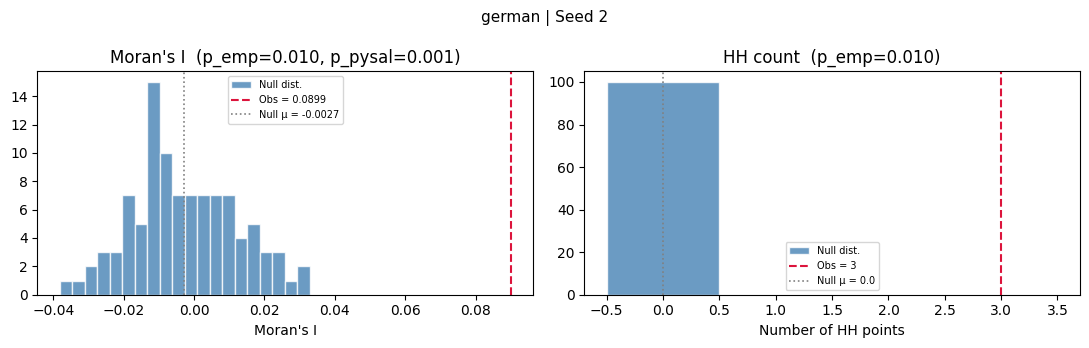

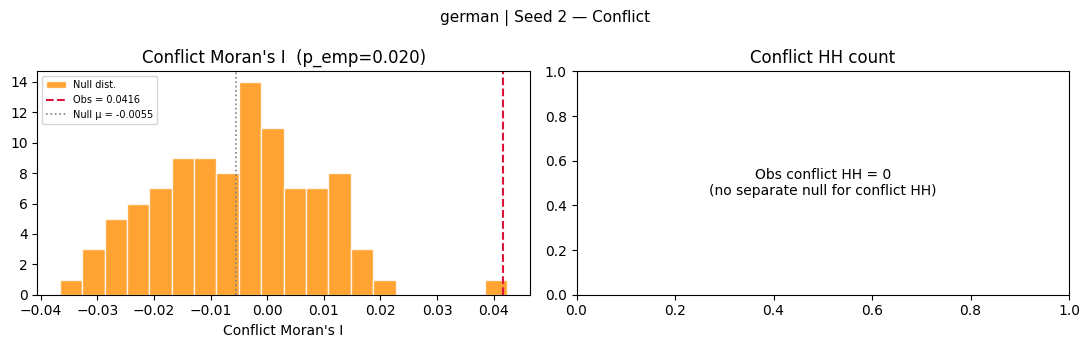

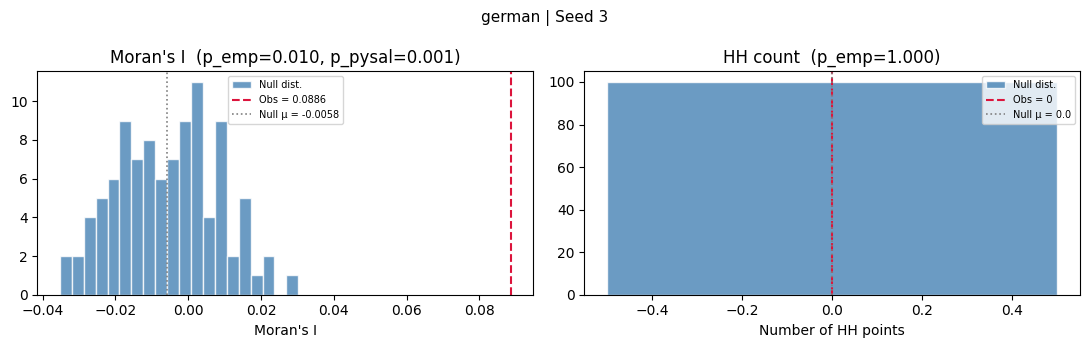

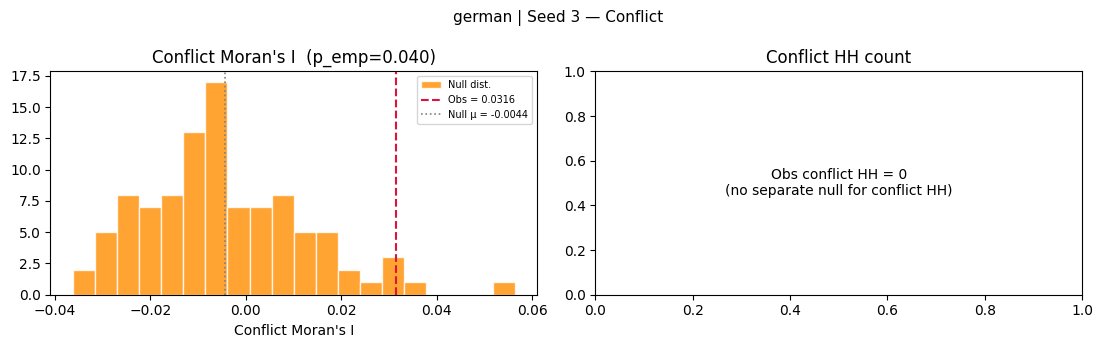

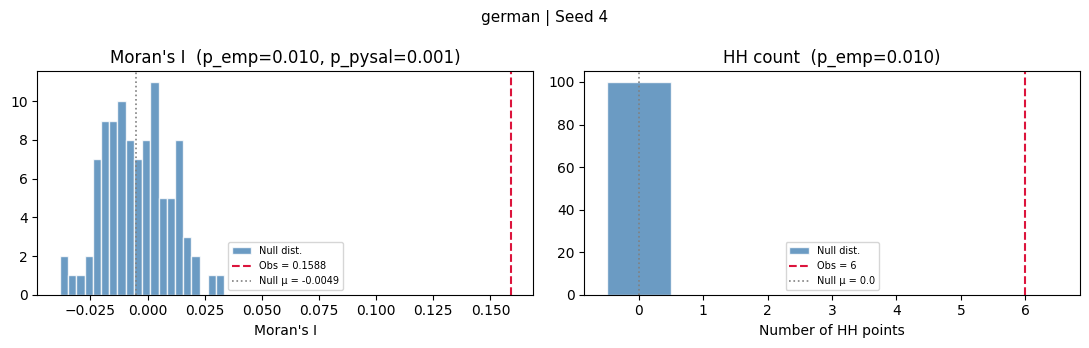

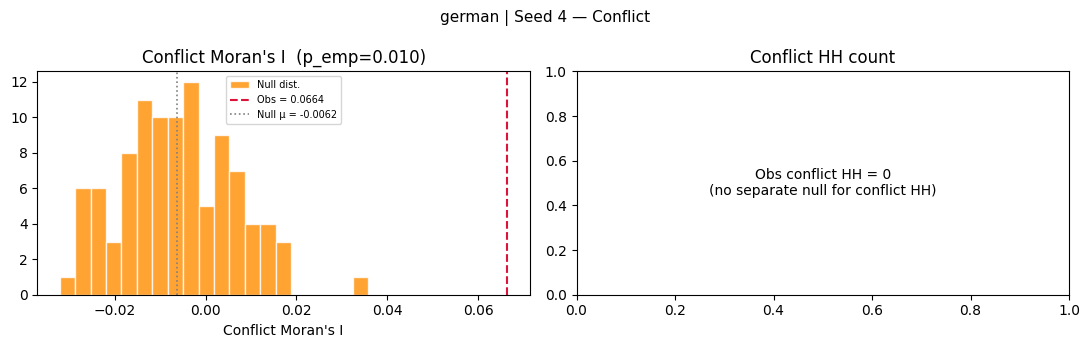

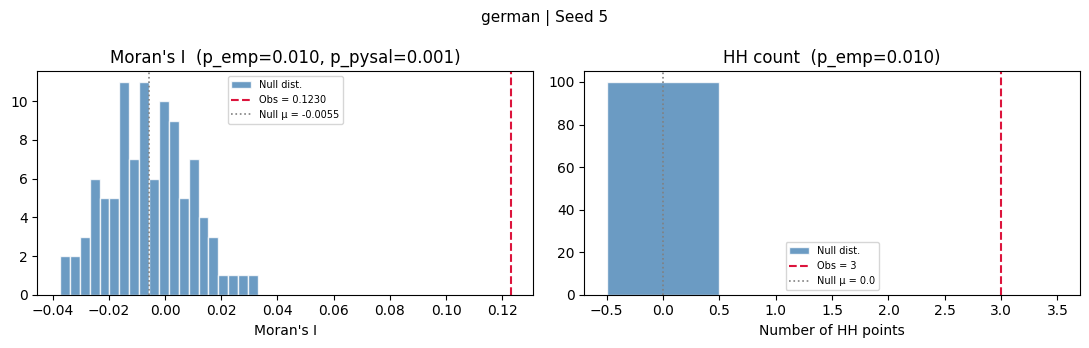

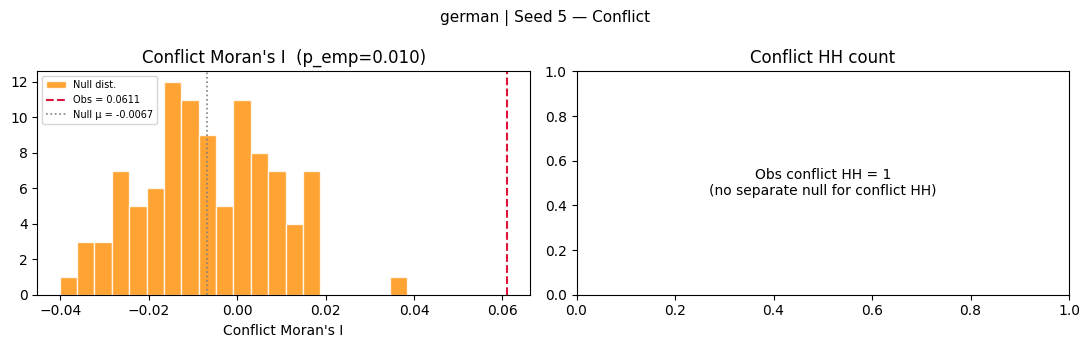

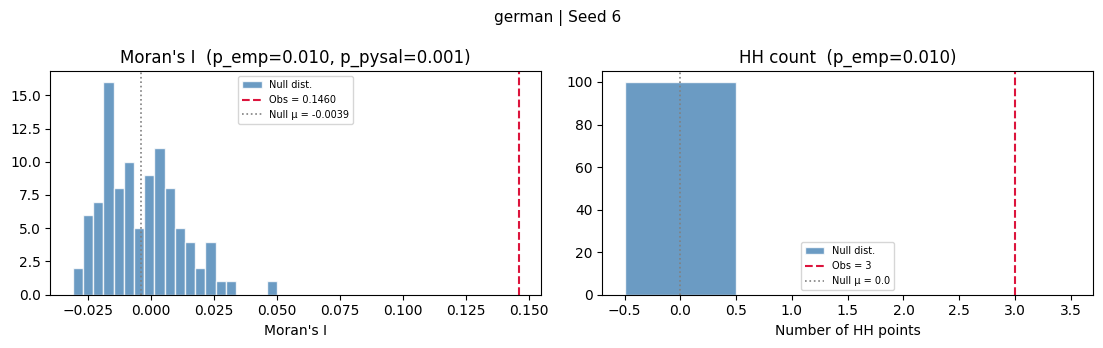

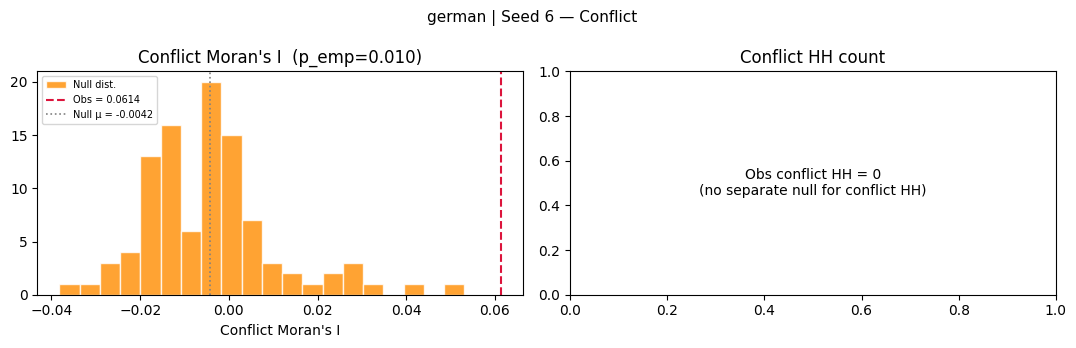

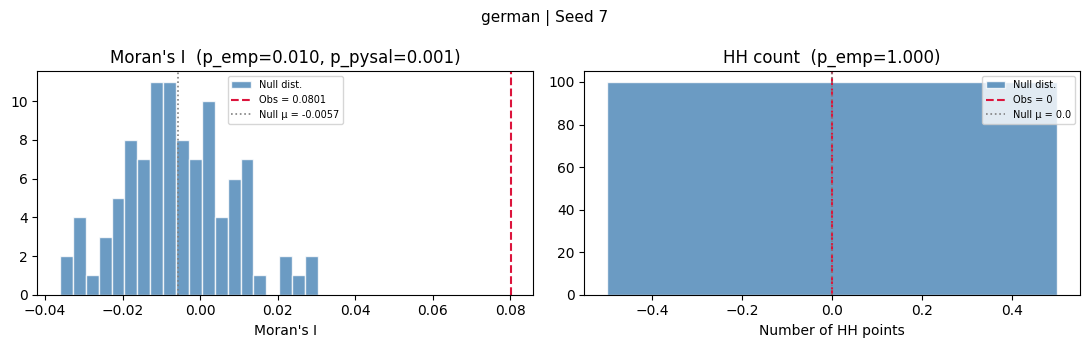

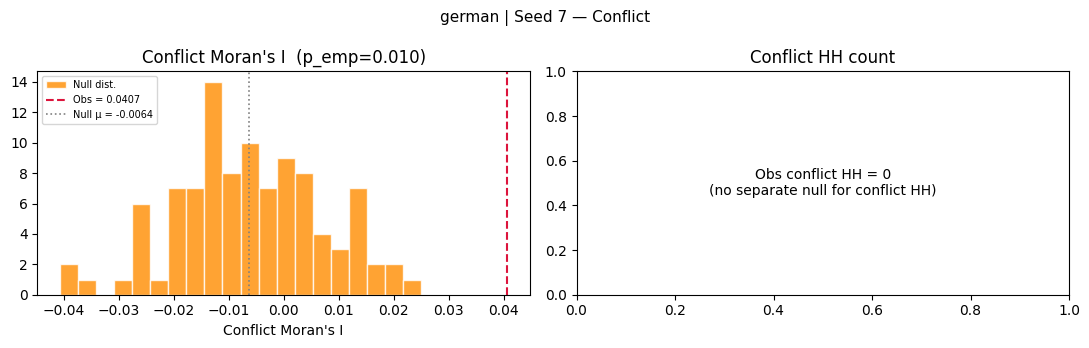

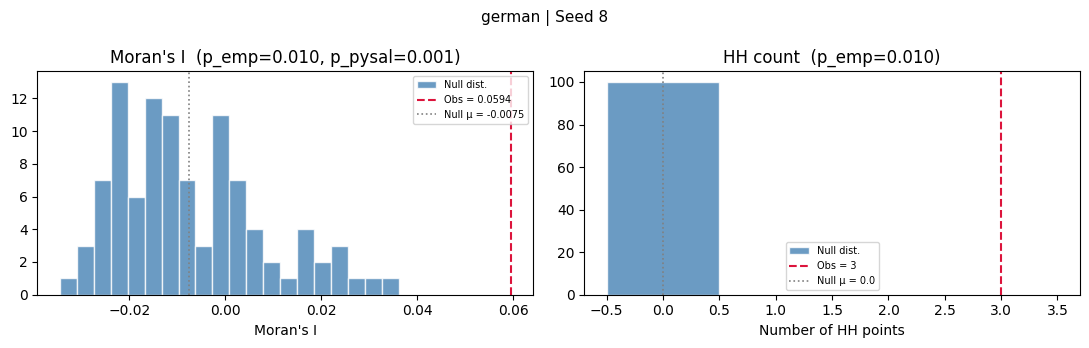

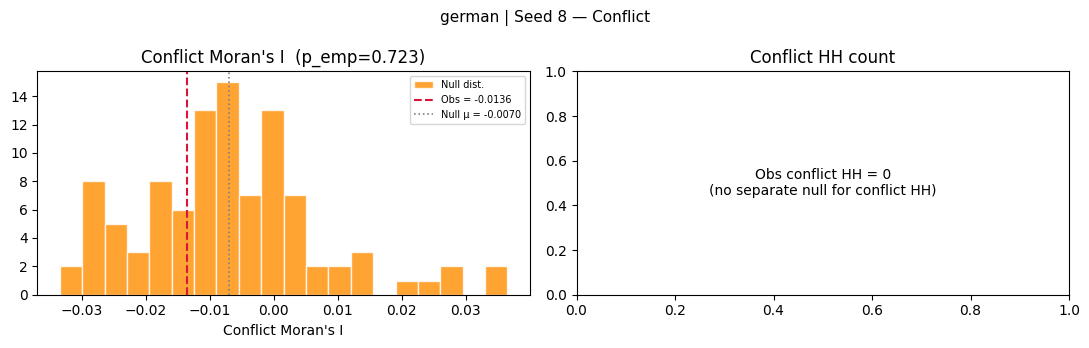

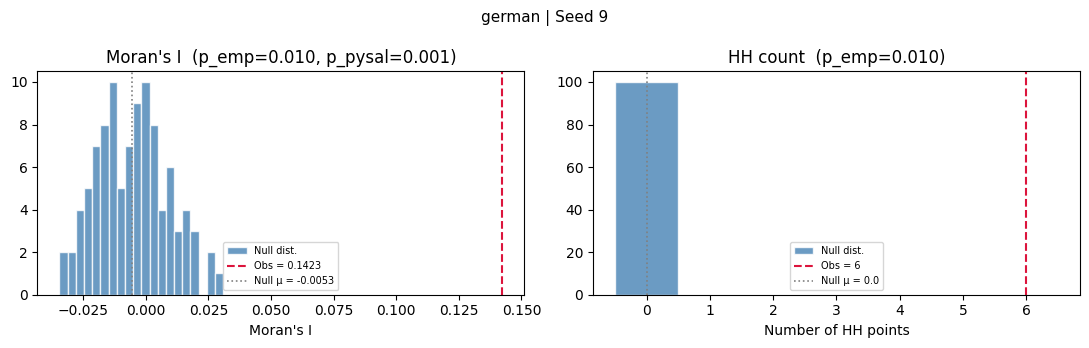

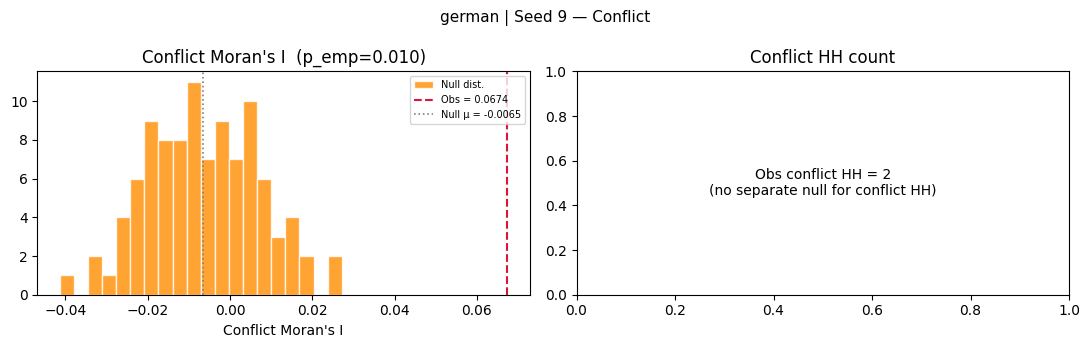

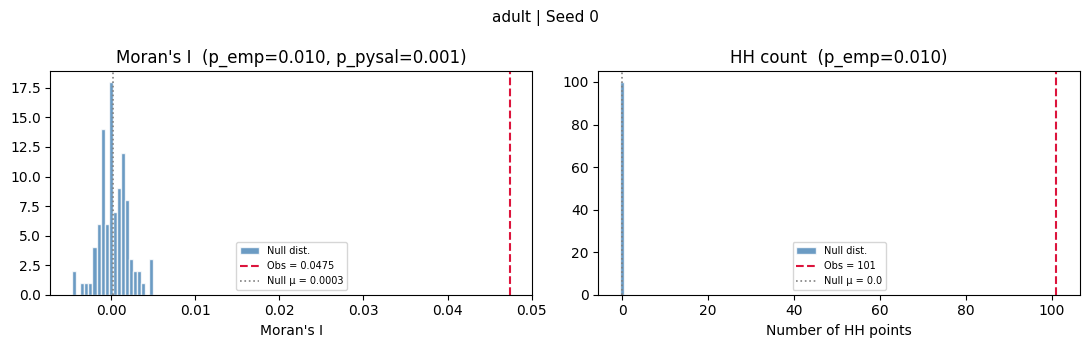

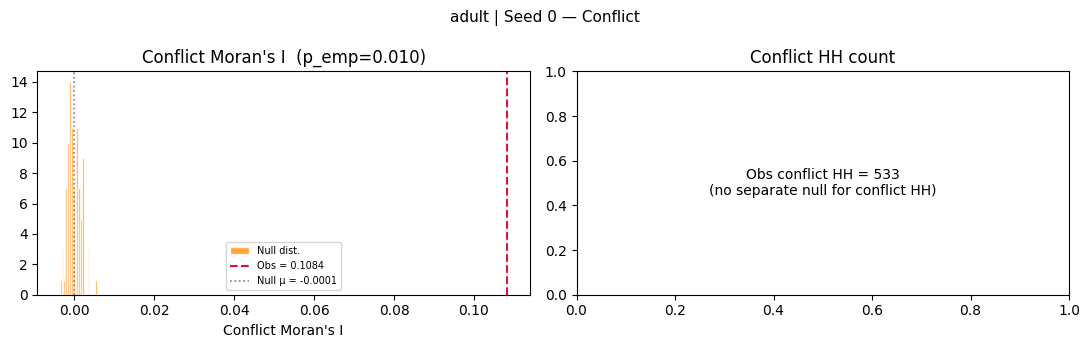

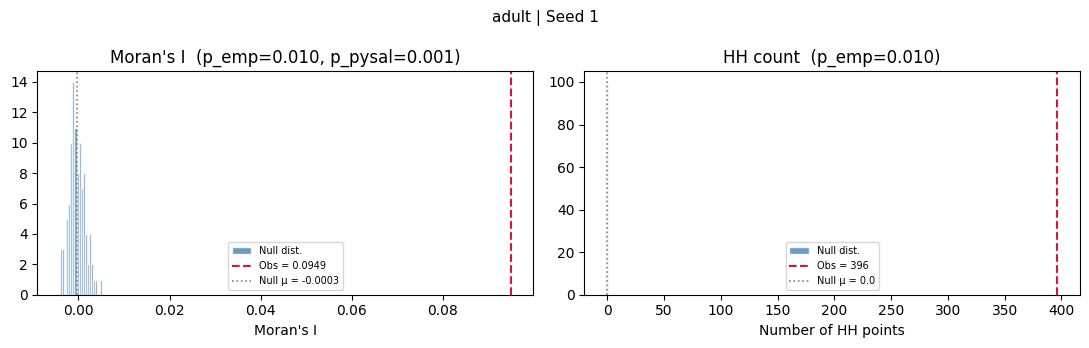

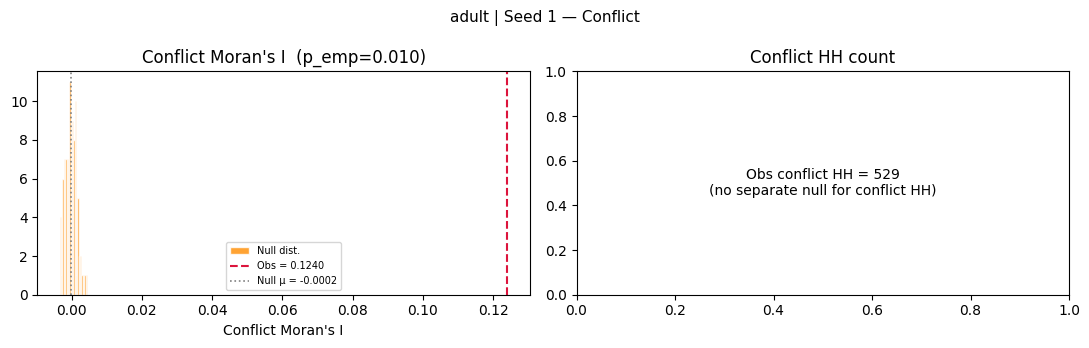

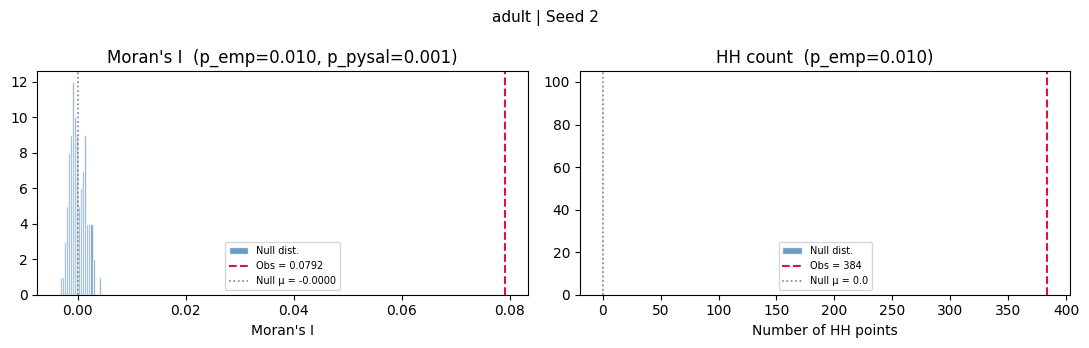

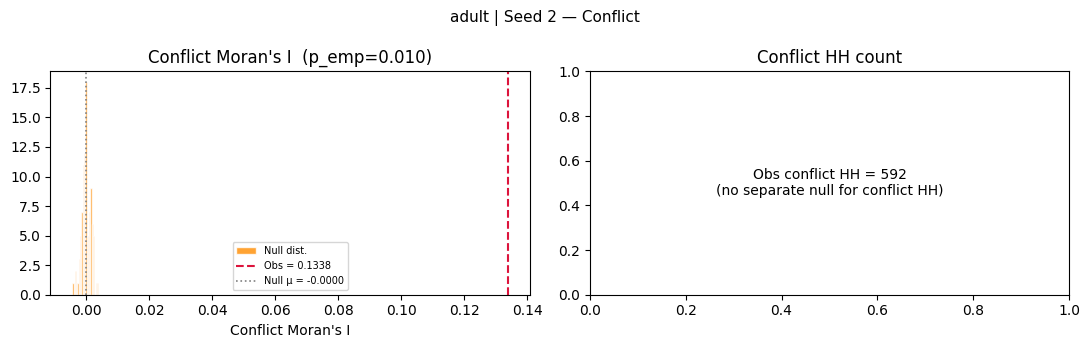

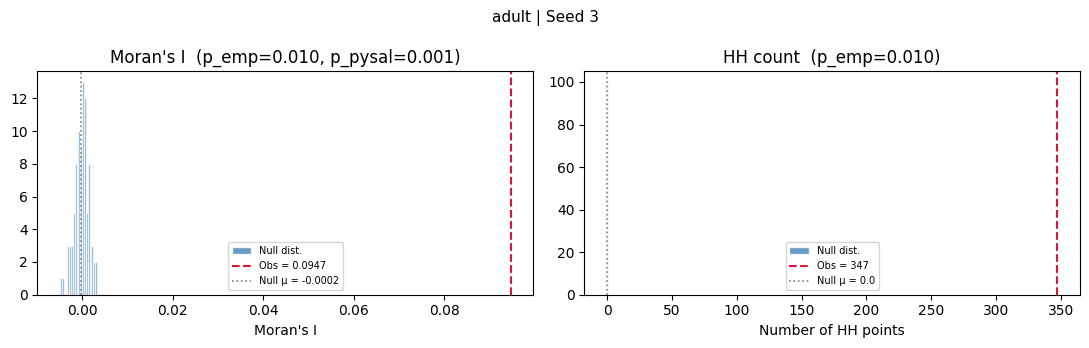

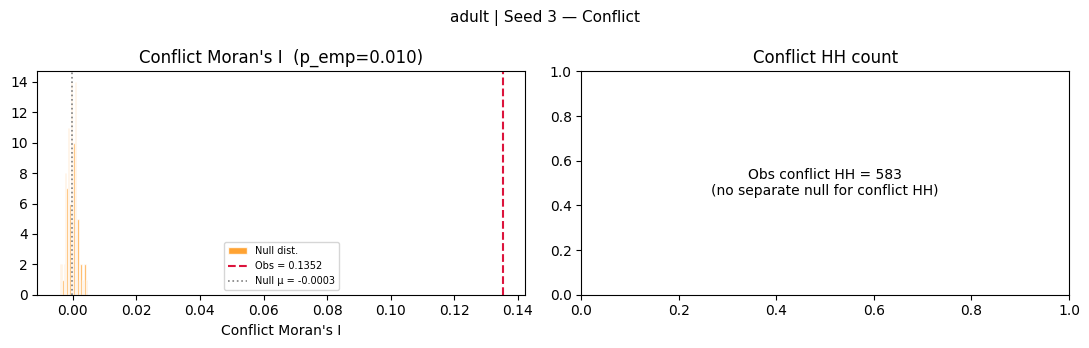

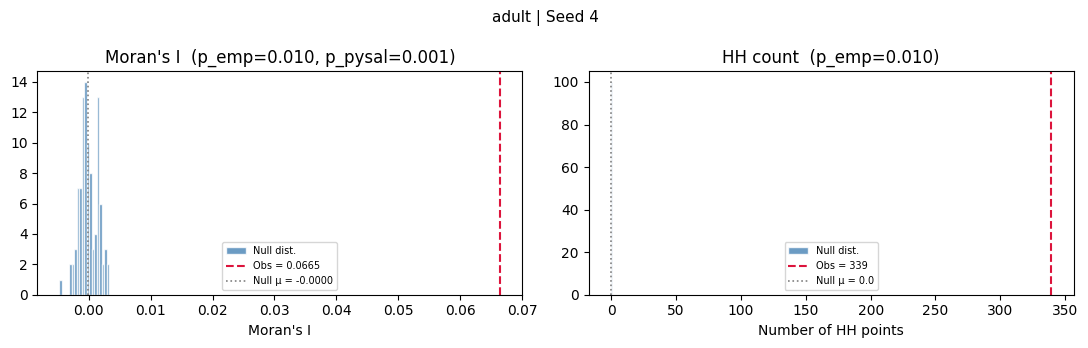

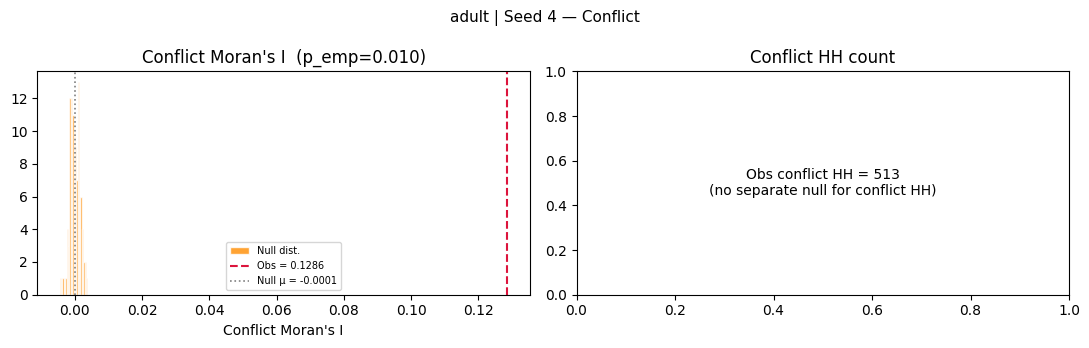

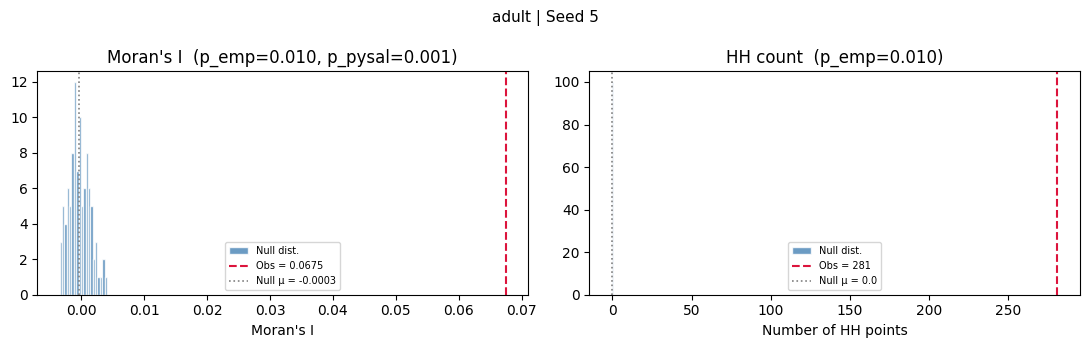

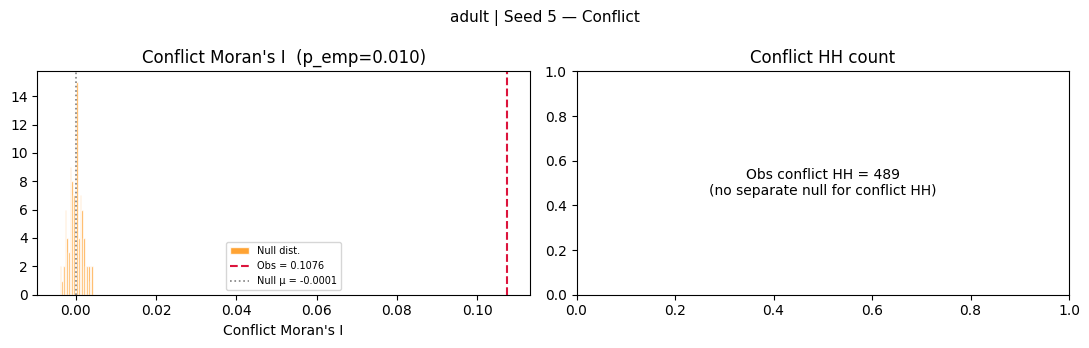

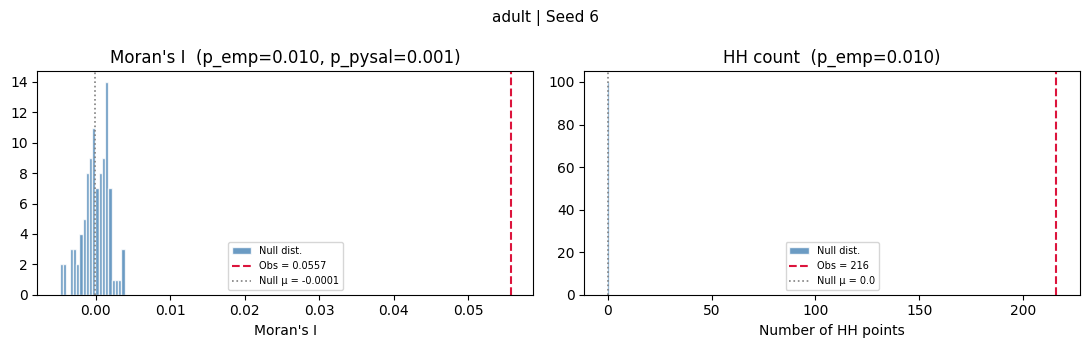

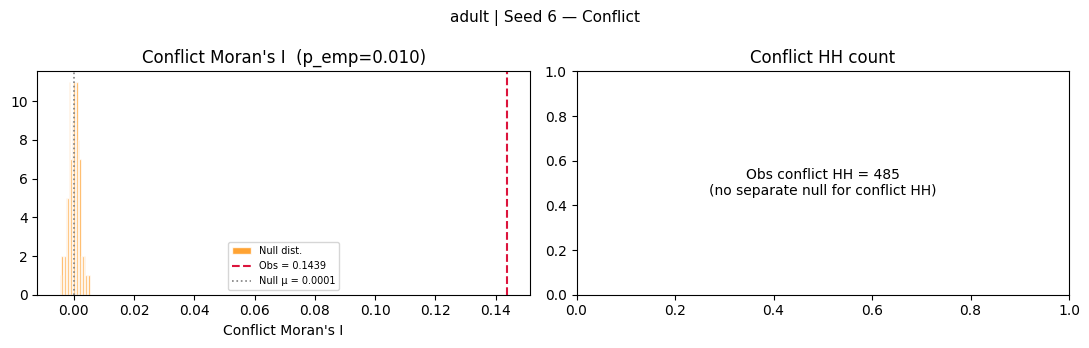

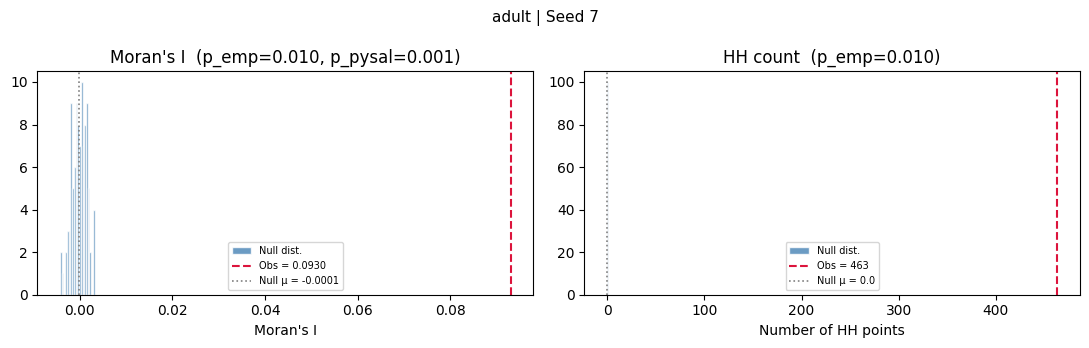

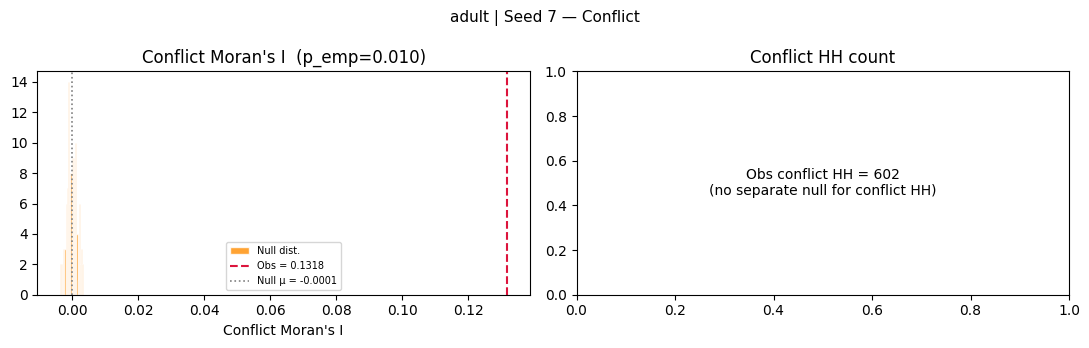

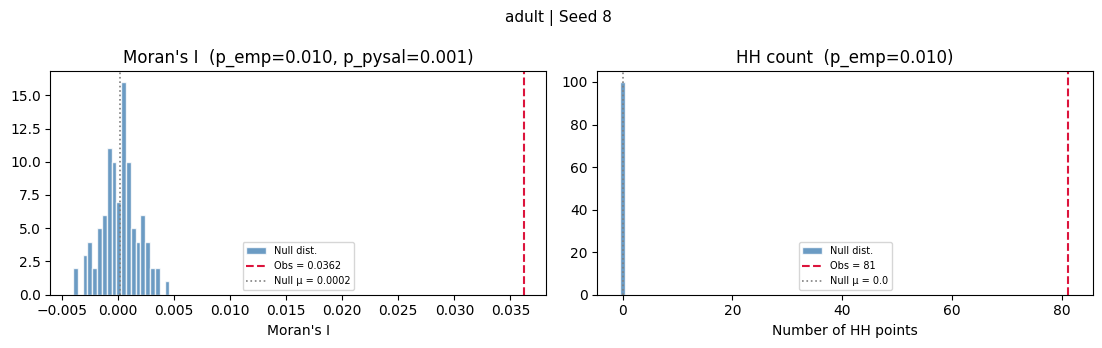

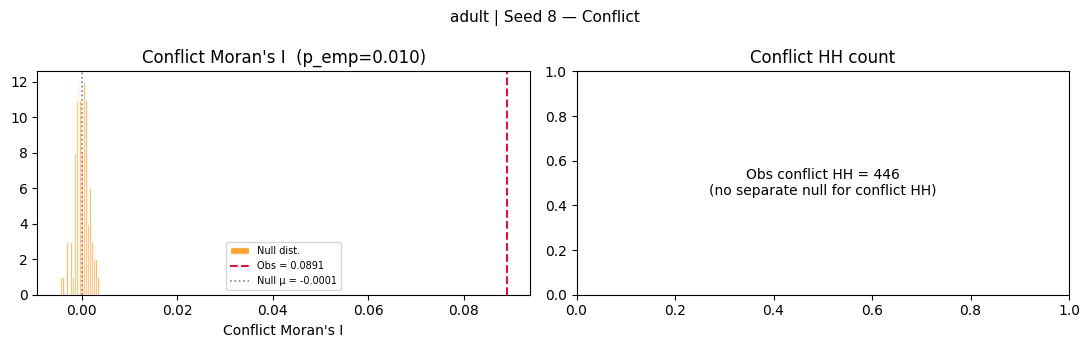

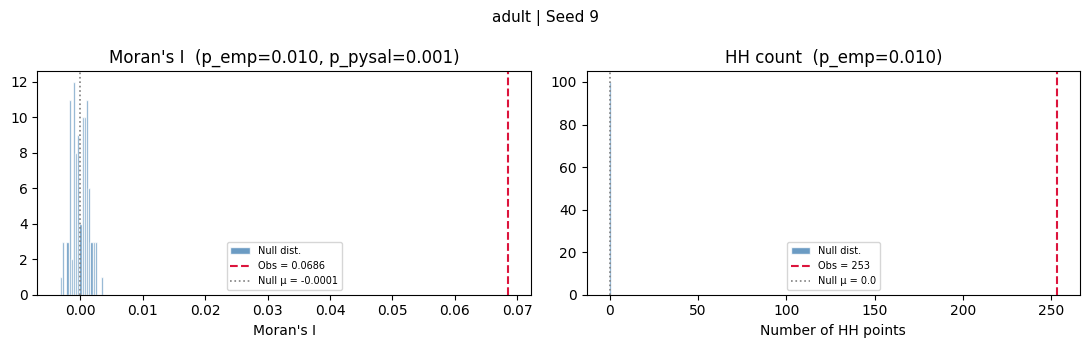

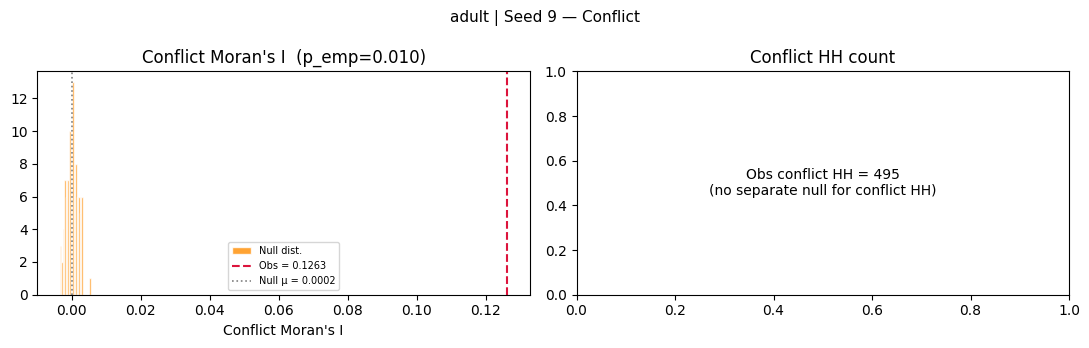

,dataset,outer_seed,obs_moran_I,moran_p_internal,null_moran_mean,null_moran_std,p_empirical_moran,sig_moran,obs_n_hh,null_n_hh_mean,null_n_hh_std,p_empirical_hh,sig_hh,obs_conflict_moran_I,obs_conflict_n_hh,null_conflict_moran_mean,null_conflict_moran_std,p_empirical_conflict,sig_conflict
0,compas,0,0.140503,0.001,-0.000672,0.006128,0.009901,True,47,0.0,0.0,0.009901,True,0.129945,76,-0.000617,0.006745,0.009901,True
1,compas,1,0.211425,0.001,-0.000711,0.006030,0.009901,True,135,0.0,0.0,0.009901,True,0.160011,94,-0.000649,0.006837,0.009901,True
2,compas,2,0.205800,0.001,0.000011,0.006051,0.009901,True,52,0.0,0.0,0.009901,True,0.128365,75,-0.001115,0.006126,0.009901,True
3,compas,3,0.360500,0.001,-0.000824,0.005856,0.009901,True,169,0.0,0.0,0.009901,True,0.217310,150,-0.001295,0.005360,0.009901,True
4,compas,4,0.110097,0.001,0.000462,0.006090,0.009901,True,20,0.0,0.0,0.009901,True,0.147456,104,-0.000409,0.005889,0.009901,True
5,compas,5,0.140545,0.001,-0.001433,0.007028,0.009901,True,49,0.0,0.0,0.009901,True,0.209522,119,-0.000532,0.006024,0.009901,True
6,compas,6,0.175005,0.001,-0.001580,0.006383,0.009901,True,97,0.0,0.0,0.009901,True,0.184343,138,-0.002519,0.005550,0.009901,True
7,compas,7,0.215078,0.001,0.000571,0.006611,0.009901,True,129,0.0,0.0,0.009901,True,0.206768,102,0.000508,0.006703,0.009901,True
8,compas,8,0.291669,0.001,0.000453,0.005947,0.009901,True,146,0.0,0.0,0.009901,True,0.174750,118,-0.001316,0.006192,0.009901,True
9,compas,9,0.142169,0.001,0.000346,0.006147,0.009901,True,23,0.0,0.0,0.009901,True,0.159222,103,-0.000586,0.006391,0.009901,True


In [2]:
K = 25
R_null = 100

DATASETS = ["compas", "german", "adult"]
dataset_dirs = [
    RESULTS_DIR / d for d in DATASETS
    if (RESULTS_DIR / d).exists() and _get_run_dirs(RESULTS_DIR / d)
]
if not dataset_dirs:
    raise SystemExit(f"No dataset dirs with runs in {RESULTS_DIR}")

run_results = []
for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    run_dirs = _get_run_dirs(dataset_dir)
    for run_dir in run_dirs:
        config = load_config(run_dir)
        outer_seed = config.get("outer_seed", int(run_dir.name.split("=")[1]) if "=" in run_dir.name else 0)
        n_cand = len(load_meta(run_dir))
        K_actual = min(K, n_cand)
        X_test = get_transformed_test_features(run_dir, dataset_name)
        k_nn = K_NN_BY_DATASET[dataset_name]
        spatial = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
        null = run_null(run_dir, X_test, K=K_actual, R=R_null, k=k_nn)
        observed_I = spatial["moran_i"]
        moran_p_sim = spatial["moran_p_sim"]
        observed_n_hh = int(np.sum(spatial["HH_mask"]))

        null_moran = null["null_moran_i"]
        null_n_hh = null["null_n_hh"]
        null_conflict_moran = null["null_conflict_moran_i"]
        null_moran_mean = null["null_mean"]
        null_moran_std = null["null_std"]
        null_n_hh_mean = null["null_n_hh_mean"]
        null_n_hh_std = null["null_n_hh_std"]

        p_emp = (1 + np.sum(null_moran >= observed_I)) / (R_null + 1)
        p_emp_hh = (1 + np.sum(null_n_hh >= observed_n_hh)) / (R_null + 1)
        obs_conflict_I = spatial.get("conflict_moran_i", float("nan"))
        obs_conflict_n_hh = int(spatial.get("conflict_n_hh", 0))
        null_conflict_mean = null.get("null_conflict_moran_mean", 0.0)
        null_conflict_std = null.get("null_conflict_moran_std", 0.0)
        p_emp_conflict = float((1 + np.sum(null_conflict_moran >= obs_conflict_I)) / (R_null + 1)) if not np.isnan(obs_conflict_I) else float("nan")
        sig_conflict = p_emp_conflict < 0.05 if not np.isnan(p_emp_conflict) else False
        significant = p_emp < 0.05
        significant_hh = p_emp_hh < 0.05

        fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

        axes[0].hist(null_moran, bins=20, color="steelblue", edgecolor="white", alpha=0.8, label="Null dist.")
        axes[0].axvline(observed_I, ls="--", color="crimson", lw=1.5, label=f"Obs = {observed_I:.4f}")
        axes[0].axvline(null_moran_mean, ls=":", color="grey", lw=1.2, label=f"Null μ = {null_moran_mean:.4f}")
        axes[0].set_xlabel("Moran's I")
        axes[0].set_title(f"Moran's I  (p_emp={p_emp:.3f}, p_pysal={moran_p_sim:.3f})")
        axes[0].legend(fontsize=7)

        axes[1].hist(null_n_hh, bins=range(0, max(int(null_n_hh.max()) + 2, observed_n_hh + 2)),
                      color="steelblue", edgecolor="white", align="left", alpha=0.8, label="Null dist.")
        axes[1].axvline(observed_n_hh, ls="--", color="crimson", lw=1.5, label=f"Obs = {observed_n_hh}")
        axes[1].axvline(null_n_hh_mean, ls=":", color="grey", lw=1.2, label=f"Null μ = {null_n_hh_mean:.1f}")
        axes[1].set_xlabel("Number of HH points")
        axes[1].set_title(f"HH count  (p_emp={p_emp_hh:.3f})")
        axes[1].legend(fontsize=7)

        fig.suptitle(f"{dataset_name} | Seed {outer_seed}", fontsize=11)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"null_moran_{dataset_name}_seed{outer_seed}.pdf")
        plt.show()

        if not np.isnan(obs_conflict_I):
            fig2, axes2 = plt.subplots(1, 2, figsize=(11, 3.5))
            axes2[0].hist(null_conflict_moran, bins=20, color="darkorange", edgecolor="white", alpha=0.8, label="Null dist.")
            axes2[0].axvline(obs_conflict_I, ls="--", color="crimson", lw=1.5, label=f"Obs = {obs_conflict_I:.4f}")
            axes2[0].axvline(null_conflict_mean, ls=":", color="grey", lw=1.2, label=f"Null μ = {null_conflict_mean:.4f}")
            axes2[0].set_xlabel("Conflict Moran's I")
            axes2[0].set_title(f"Conflict Moran's I  (p_emp={p_emp_conflict:.3f})")
            axes2[0].legend(fontsize=7)

            axes2[1].text(0.5, 0.5, f"Obs conflict HH = {obs_conflict_n_hh}\n(no separate null for conflict HH)",
                         ha="center", va="center", fontsize=10, transform=axes2[1].transAxes)
            axes2[1].set_title("Conflict HH count")

            fig2.suptitle(f"{dataset_name} | Seed {outer_seed} — Conflict", fontsize=11)
            fig2.tight_layout()
            fig2.savefig(FIG_DIR / f"null_conflict_moran_{dataset_name}_seed{outer_seed}.pdf")
            plt.show()

        run_results.append({
            "dataset": dataset_name,
            "outer_seed": outer_seed,
            # Moran's I
            "obs_moran_I": observed_I,
            "moran_p_internal": moran_p_sim,
            "null_moran_mean": null_moran_mean,
            "null_moran_std": null_moran_std,
            "p_empirical_moran": p_emp,
            "sig_moran": significant,
            # LISA HH count
            "obs_n_hh": observed_n_hh,
            "null_n_hh_mean": null_n_hh_mean,
            "null_n_hh_std": null_n_hh_std,
            "p_empirical_hh": p_emp_hh,
            "sig_hh": significant_hh,
            "obs_conflict_moran_I": obs_conflict_I,
            "obs_conflict_n_hh": obs_conflict_n_hh,
            "null_conflict_moran_mean": null_conflict_mean,
            "null_conflict_moran_std": null_conflict_std,
            "p_empirical_conflict": p_emp_conflict,
            "sig_conflict": sig_conflict,
        })

run_results = pd.DataFrame(run_results)
run_results

## Summary: Observed vs. Null comparison

Two types of p-values are reported:

| Name | What it tests |
|---|---|
| **p_pysal (internal perm.)** | PySAL permutes the **variance vector** against the spatial weights (999 internal permutations). Tests whether the observed Moran's I is significant given the spatial structure. |
| **p_empirical (pred. perm.)** | We permute the **model predictions** independently (breaking spatial dependence), recompute variance, then Moran's I. The empirical p-value is the fraction of null replicates where Moran's I ≥ observed. Tests whether the spatial clustering arises from genuine predictive multiplicity rather than chance. |

In [3]:
def _fmt(m, s):
    return f"{m:.4f} ± {s:.4f}" if pd.notna(s) else f"{m:.4f}"

# ── Moran's I comparison ──
moran_agg = run_results.groupby("dataset").agg(
    n_runs=("sig_moran", "count"),
    obs_mean=("obs_moran_I", "mean"),
    obs_std=("obs_moran_I", "std"),
    null_mean=("null_moran_mean", "mean"),
    null_std=("null_moran_std", "mean"),
    p_internal_mean=("moran_p_internal", "mean"),
    p_empirical_mean=("p_empirical_moran", "mean"),
    frac_sig=("sig_moran", "mean"),
).reset_index()

moran_tbl = pd.DataFrame({
    "Dataset": moran_agg["dataset"],
    "Runs": moran_agg["n_runs"],
    "Observed I (mean±std)": moran_agg.apply(lambda r: _fmt(r.obs_mean, r.obs_std), axis=1),
    "Null I (mean±std)": moran_agg.apply(lambda r: _fmt(r.null_mean, r.null_std), axis=1),
    "p_pysal (internal perm.)": moran_agg["p_internal_mean"].map("{:.4f}".format),
    "p_empirical (pred. perm.)": moran_agg["p_empirical_mean"].map("{:.4f}".format),
    "Frac. sig. (p_emp < 0.05)": moran_agg["frac_sig"].map("{:.0%}".format),
})

print("=" * 90)
print("MORAN'S I — Observed vs. Null")
print("-" * 90)
print("  p_pysal (internal perm.)  : PySAL's own permutation p-value for Moran's I")
print("  p_empirical (pred. perm.) : our null experiment (permuted predictions)")
print("=" * 90)
display(moran_tbl)

# ── LISA n_HH comparison ──
lisa_agg = run_results.groupby("dataset").agg(
    n_runs=("sig_hh", "count"),
    obs_mean=("obs_n_hh", "mean"),
    obs_std=("obs_n_hh", "std"),
    null_mean=("null_n_hh_mean", "mean"),
    null_std=("null_n_hh_std", "mean"),
    p_empirical_mean=("p_empirical_hh", "mean"),
    frac_sig=("sig_hh", "mean"),
).reset_index()

lisa_tbl = pd.DataFrame({
    "Dataset": lisa_agg["dataset"],
    "Runs": lisa_agg["n_runs"],
    "Observed n_HH (mean±std)": lisa_agg.apply(
        lambda r: f"{r.obs_mean:.1f} ± {r.obs_std:.1f}" if pd.notna(r.obs_std) else f"{r.obs_mean:.1f}", axis=1),
    "Null n_HH (mean±std)": lisa_agg.apply(
        lambda r: f"{r.null_mean:.2f} ± {r.null_std:.2f}", axis=1),
    "p_empirical (pred. perm.)": lisa_agg["p_empirical_mean"].map("{:.4f}".format),
    "Frac. sig. (p_emp < 0.05)": lisa_agg["frac_sig"].map("{:.0%}".format),
})

print("\n" + "=" * 90)
print("LISA HOT SPOTS (n_HH) — Observed vs. Null")
print("-" * 90)
print("  p_empirical (pred. perm.) : our null experiment (permuted predictions)")
print("=" * 90)
display(lisa_tbl)

# Save combined summary
combined = moran_agg.merge(lisa_agg, on=["dataset", "n_runs"], suffixes=("_moran", "_hh"))
combined.to_csv(TABLE_DIR / "null_significance_summary.csv", index=False)

# ── Conflict Moran's I comparison ──
print("\n" + "=" * 90)
print("CONFLICT MORAN'S I — Observed vs. Null")
print("-" * 90)
print("=" * 90)

conflict_agg = run_results.groupby("dataset").agg(
    n_runs=("sig_conflict", "count"),
    obs_mean=("obs_conflict_moran_I", "mean"),
    obs_std=("obs_conflict_moran_I", "std"),
    null_mean=("null_conflict_moran_mean", "mean"),
    null_std=("null_conflict_moran_std", "mean"),
    p_empirical_mean=("p_empirical_conflict", "mean"),
    frac_sig=("sig_conflict", "mean"),
).reset_index()

conflict_tbl = pd.DataFrame({
    "Dataset": conflict_agg["dataset"],
    "Runs": conflict_agg["n_runs"],
    "Observed conflict I (mean±std)": conflict_agg.apply(lambda r: _fmt(r.obs_mean, r.obs_std), axis=1),
    "Null conflict I (mean±std)": conflict_agg.apply(lambda r: _fmt(r.null_mean, r.null_std), axis=1),
    "p_empirical": conflict_agg["p_empirical_mean"].map("{:.4f}".format),
    "Frac. sig. (p_emp < 0.05)": conflict_agg["frac_sig"].map("{:.0%}".format),
})
display(conflict_tbl)

MORAN'S I — Observed vs. Null
------------------------------------------------------------------------------------------
  p_pysal (internal perm.)  : PySAL's own permutation p-value for Moran's I
  p_empirical (pred. perm.) : our null experiment (permuted predictions)


,Dataset,Runs,Observed I (mean±std),Null I (mean±std),p_pysal (internal perm.),p_empirical (pred. perm.),Frac. sig. (p_emp < 0.05)
0,adult,10,0.0704 ± 0.0203,-0.0001 ± 0.0016,0.0010,0.0099,100%
1,compas,10,0.1993 ± 0.0772,-0.0003 ± 0.0062,0.0010,0.0099,100%
2,german,10,0.1042 ± 0.0397,-0.0055 ± 0.0146,0.0015,0.0099,100%



LISA HOT SPOTS (n_HH) — Observed vs. Null
------------------------------------------------------------------------------------------
  p_empirical (pred. perm.) : our null experiment (permuted predictions)


,Dataset,Runs,Observed n_HH (mean±std),Null n_HH (mean±std),p_empirical (pred. perm.),Frac. sig. (p_emp < 0.05)
0,adult,10,286.1 ± 125.5,0.00 ± 0.00,0.0099,100%
1,compas,10,86.7 ± 55.0,0.00 ± 0.00,0.0099,100%
2,german,10,2.7 ± 2.2,0.00 ± 0.00,0.3069,70%



CONFLICT MORAN'S I — Observed vs. Null
------------------------------------------------------------------------------------------


,Dataset,Runs,Observed conflict I (mean±std),Null conflict I (mean±std),p_empirical,Frac. sig. (p_emp < 0.05)
0,adult,10,0.1229 ± 0.0164,-0.0001 ± 0.0016,0.0099,100%
1,compas,10,0.1718 ± 0.0323,-0.0009 ± 0.0062,0.0099,100%
2,german,10,0.0525 ± 0.0304,-0.0059 ± 0.0144,0.0851,90%


## Per-run details

Full per-run table with both Moran's I and LISA statistics, including null distribution parameters and both p-value types.

In [4]:
display_cols_moran = [
    "dataset", "outer_seed",
    "obs_moran_I", "null_moran_mean", "null_moran_std",
    "moran_p_internal", "p_empirical_moran", "sig_moran",
]
display_cols_hh = [
    "dataset", "outer_seed",
    "obs_n_hh", "null_n_hh_mean", "null_n_hh_std",
    "p_empirical_hh", "sig_hh",
]

styled_moran = (
    run_results[display_cols_moran]
    .style
    .format({
        "obs_moran_I": "{:.4f}",
        "null_moran_mean": "{:.4f}",
        "null_moran_std": "{:.4f}",
        "moran_p_internal": "{:.4f}",
        "p_empirical_moran": "{:.4f}",
    })
    .set_caption("Per-run Moran's I  (moran_p_internal = PySAL internal perm., p_empirical_moran = pred. perm.)")
)

styled_hh = (
    run_results[display_cols_hh]
    .style
    .format({
        "null_n_hh_mean": "{:.2f}",
        "null_n_hh_std": "{:.2f}",
        "p_empirical_hh": "{:.4f}",
    })
    .set_caption("Per-run LISA n_HH  (p_empirical_hh = pred. perm.)")
)

display(styled_moran)
print()
display(styled_hh)

,dataset,outer_seed,obs_moran_I,null_moran_mean,null_moran_std,moran_p_internal,p_empirical_moran,sig_moran
0,compas,0,0.1405,-0.0007,0.0061,0.0010,0.0099,True
1,compas,1,0.2114,-0.0007,0.0060,0.0010,0.0099,True
2,compas,2,0.2058,0.0000,0.0061,0.0010,0.0099,True
3,compas,3,0.3605,-0.0008,0.0059,0.0010,0.0099,True
4,compas,4,0.1101,0.0005,0.0061,0.0010,0.0099,True
5,compas,5,0.1405,-0.0014,0.0070,0.0010,0.0099,True
6,compas,6,0.1750,-0.0016,0.0064,0.0010,0.0099,True
7,compas,7,0.2151,0.0006,0.0066,0.0010,0.0099,True
8,compas,8,0.2917,0.0005,0.0059,0.0010,0.0099,True
9,compas,9,0.1422,0.0003,0.0061,0.0010,0.0099,True


,dataset,outer_seed,obs_n_hh,null_n_hh_mean,null_n_hh_std,p_empirical_hh,sig_hh
0,compas,0,47,0.00,0.00,0.0099,True
1,compas,1,135,0.00,0.00,0.0099,True
2,compas,2,52,0.00,0.00,0.0099,True
3,compas,3,169,0.00,0.00,0.0099,True
4,compas,4,20,0.00,0.00,0.0099,True
5,compas,5,49,0.00,0.00,0.0099,True
6,compas,6,97,0.00,0.00,0.0099,True
7,compas,7,129,0.00,0.00,0.0099,True
8,compas,8,146,0.00,0.00,0.0099,True
9,compas,9,23,0.00,0.00,0.0099,True


## Aggregated null summary

Boxplot of observed Moran's I vs null mean ± std across seeds, showing significance across runs as a z-score: z = (observed - null_mean) / null_std.

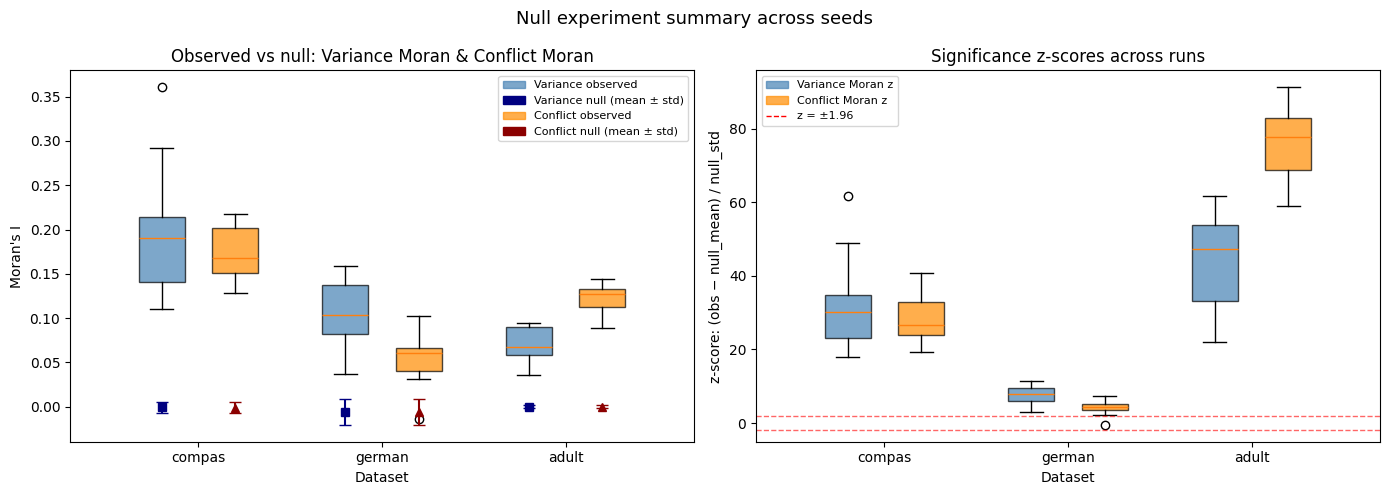

In [5]:
import matplotlib.patches as mpatches

datasets_in_results = run_results["dataset"].unique()
n_ds = len(datasets_in_results)
x_base = np.arange(n_ds)
box_labels = list(datasets_in_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# ── Left panel: BOTH Variance Moran and Conflict Moran (observed vs null) ──
pos_var = x_base - 0.2
pos_conf = x_base + 0.2

box_var = [run_results[run_results["dataset"] == ds]["obs_moran_I"].values for ds in datasets_in_results]
box_conf = [run_results[run_results["dataset"] == ds]["obs_conflict_moran_I"].values for ds in datasets_in_results]
null_var_mean = [run_results[run_results["dataset"] == ds]["null_moran_mean"].mean() for ds in datasets_in_results]
null_var_std = [run_results[run_results["dataset"] == ds]["null_moran_std"].mean() for ds in datasets_in_results]
null_conf_mean = [run_results[run_results["dataset"] == ds]["null_conflict_moran_mean"].mean() for ds in datasets_in_results]
null_conf_std = [run_results[run_results["dataset"] == ds]["null_conflict_moran_std"].mean() for ds in datasets_in_results]

bp_var = axes[0].boxplot(box_var, tick_labels=box_labels, patch_artist=True, widths=0.25, positions=pos_var)
for patch in bp_var["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.7)
axes[0].errorbar(pos_var, null_var_mean, yerr=null_var_std, fmt="s", color="navy", capsize=4, markersize=6, label="Variance null")

bp_conf = axes[0].boxplot(box_conf, tick_labels=box_labels, patch_artist=True, widths=0.25, positions=pos_conf)
for patch in bp_conf["boxes"]:
    patch.set_facecolor("darkorange")
    patch.set_alpha(0.7)
axes[0].errorbar(pos_conf, null_conf_mean, yerr=null_conf_std, fmt="^", color="darkred", capsize=4, markersize=6, label="Conflict null")

axes[0].set_xticks(x_base)
axes[0].set_xticklabels(box_labels)
axes[0].set_ylabel("Moran's I")
axes[0].set_xlabel("Dataset")
axes[0].set_title("Observed vs null: Variance Moran & Conflict Moran")
axes[0].legend(handles=[
    mpatches.Patch(color="steelblue", alpha=0.7, label="Variance observed"),
    mpatches.Patch(color="navy", alpha=1, label="Variance null (mean ± std)"),
    mpatches.Patch(color="darkorange", alpha=0.7, label="Conflict observed"),
    mpatches.Patch(color="darkred", alpha=1, label="Conflict null (mean ± std)"),
], fontsize=8)

# ── Right panel: Z-scores for both variance Moran and conflict Moran ──
z_data_var = []
z_data_conflict = []
for ds in datasets_in_results:
    sub = run_results[run_results["dataset"] == ds]
    z_var = (sub["obs_moran_I"] - sub["null_moran_mean"]) / sub["null_moran_std"].replace(0, float("nan"))
    z_data_var.append(z_var.dropna().values)
    z_conf = (sub["obs_conflict_moran_I"] - sub["null_conflict_moran_mean"]) / sub["null_conflict_moran_std"].replace(0, float("nan"))
    z_data_conflict.append(z_conf.dropna().values)

bp_zv = axes[1].boxplot(z_data_var, tick_labels=box_labels, patch_artist=True, widths=0.25, positions=pos_var)
for patch in bp_zv["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.7)
bp_zc = axes[1].boxplot(z_data_conflict, tick_labels=box_labels, patch_artist=True, widths=0.25, positions=pos_conf)
for patch in bp_zc["boxes"]:
    patch.set_facecolor("darkorange")
    patch.set_alpha(0.7)

axes[1].axhline(1.96, ls="--", color="red", lw=1, alpha=0.6)
axes[1].axhline(-1.96, ls="--", color="red", lw=1, alpha=0.6)
axes[1].set_xticks(x_base)
axes[1].set_xticklabels(box_labels)
axes[1].set_ylabel("z-score: (obs − null_mean) / null_std")
axes[1].set_xlabel("Dataset")
axes[1].set_title("Significance z-scores across runs")
axes[1].legend(handles=[
    mpatches.Patch(color="steelblue", alpha=0.7, label="Variance Moran z"),
    mpatches.Patch(color="darkorange", alpha=0.7, label="Conflict Moran z"),
    plt.Line2D([0], [0], color="red", ls="--", lw=1, label="z = ±1.96"),
], fontsize=8)

fig.suptitle("Null experiment summary across seeds", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "null_summary_across_seeds.pdf", bbox_inches="tight")
plt.show()